# SAE 2.02 - Exploitation algorithmique d'un problème

In [62]:
from numpy.random import randint 
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
import networkx as nx

A = np.array([
 [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0]],dtype = float)


In [63]:
def norme(X) :
    return np.sqrt(np.sum(X**2))

def creeMatriceAleatoire (i):
    return np.random.rand(i);

def puissanceIteree (A,e,Xo) :
    Xn = Xo.copy()
    XnOld = np.zeros(len(A))
    #Pour complètement implémenter l'algorithme, on doit séparer le cas si la matrice est stochastique ou non.
    if (estStochastique(A)) :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn.copy()
    else :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn / norme(AXn)
    T = []
    for i in range (len(Xn)) :
        T.append((i + 1,Xn[i]))
    return sorted(T, key= lambda x : x[1],reverse = True)

def puissanceItereeSansClassement (A,e,Xo) :
    Xn = Xo.copy()
    XnOld = np.zeros(len(A))
    #Pour complètement implémenter l'algorithme, on doit séparer le cas si la matrice est stochastique ou non.
    if (estStochastique(A)) :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn.copy()
    else :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn / norme(AXn)
    return Xn


def stochastique(A) :
    M = A.copy()
    for i in range (len(A)):
        temp = 0
        for j in range (len(A)) :
            if (A[j][i] == 1.0) :
                temp += 1
        for k in range (len(A)) :
            if (A[k][i] == 1.0) :
                M[k][i] /= temp
    return M

def estStochastique(A) :
    for i in range (A.shape[0]):
        temp = 0
        for j in range (A.shape[0]) :
            temp += A[j][i]
        if (temp != 1.0):
            return False
    return True

def transposee(A) :
    return A.T


def solutionEquation(V,W) :
    return norme(V - W)

# r est notre vecteur retourné dans l'algorithme ci-dessus
def verification(Q,e) : 
    r = puissanceItereeSansClassement(Q,e,Xo)
    # r est notre vecteur retourné dans l'algorithme ci-dessus
    R = solutionEquation(r, Q.dot(r))
    #R va nous afficher l'écart (sensé tendre vers le nul) entre r et Q*r
    if (R > 1e-5):     #ici, 1e-5 est la marge d'erreur
        return "le vecteur retourné n'est pas solution de l'équation : r = Qr", R
    else : 
        return "le vecteur retourné est solution de l'équation : la norme de r = Qr = ", R

Xo = creeMatriceAleatoire(len(A))

Q = (stochastique(transposee(A)))
e = 10**(-10)
print ("Vecteur de score obtenu :\n\n",puissanceIteree (Q,e,Xo),"\n\nLe classement est sous la forme (numero de la page,score)\n")
print (verification(Q,e))

Vecteur de score obtenu :

 [(6, 1.0552102209232794), (10, 0.8793418514224411), (1, 0.8793418501163583), (8, 0.7034734806155196), (11, 0.35173674061144816), (12, 0.35173674061144816), (13, 0.35173674061144816), (14, 0.35173674061144816), (7, 0.3517367403077598), (9, 0.3517367403077598), (2, 0.3517367400040717), (3, 0.3517367400040717), (4, 0.3517367400040717), (5, 0.3517367400040717)] 

Le classement est sous la forme (numero de la page,score)

("le vecteur retourné est solution de l'équation : la norme de r = Qr = ", 8.819432104369149e-11)


## Partie 2 : PageRank - version itérative, deuxième exemple

In [64]:
#B est le graphe d'ordre 5.
B = np.array([
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 1, 0],
 [1, 1, 0, 0, 0],
 [1, 1, 0, 0, 0]], dtype = float)

Q = (transposee(B))

Xo = creeMatriceAleatoire(len(B))

print(Q)
print('\n')
print(puissanceIteree(Q, e,Xo))

[[0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]


[(1, nan), (2, nan), (3, nan), (4, nan), (5, nan)]


/tmp/ipykernel_71701/1839254982.py:20: RuntimeWarning: invalid value encountered in divide
  Xn = AXn / norme(AXn)


In [65]:
#Question 2

def matriceTransition(A,B,a) :
    M = np.zeros((len(A),len(A)))
    for i in range (len(A)):
        for j in range (len(A)) :
            if (sommeTableau(j,A) != 0):    
                M[i][j] = a*B[i][j] + (1-a)/len(A)
            else:
                M[i][j] = 1/len(A)
    return M       

def sommeTableau(j,A) :
    temp = 0
    for i in range (A.shape[0]):
        temp += A[i][j]
    return (temp)

a = 0.85
Xo = creeMatriceAleatoire(len(B))
P = matriceTransition(transposee(B),stochastique(transposee(B)),a)
print (P,"\n")
print (puissanceIteree(P,e,Xo),"\n")
print(verification(P,e))

[[0.2   0.88  0.455 0.455 0.455]
 [0.2   0.03  0.03  0.455 0.455]
 [0.2   0.03  0.03  0.03  0.03 ]
 [0.2   0.03  0.455 0.03  0.03 ]
 [0.2   0.03  0.03  0.03  0.03 ]] 

[(1, 1.123922262507399), (2, 0.5457800708196252), (4, 0.38300355846718315), (3, 0.26877442698934184), (5, 0.26877442698934184)] 

("le vecteur retourné est solution de l'équation : la norme de r = Qr = ", 2.621599582634272e-11)


## Partie 3 : PageRank - version itérative, analyse des paramètres

In [66]:
#Question 1

def equation(Q,e) : 
    r = puissanceItereeSansClassement(Q,e,Xo)
    # r est notre vecteur retourné dans l'algorithme ci-dessus
    return solutionEquation(r, Q.dot(r))

Xo = creeMatriceAleatoire(len(A))

Q = (stochastique(transposee(A)))

tab = []

e = 1
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
e = 0.1
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-2
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e= 1e-4
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-6
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-8
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-10
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-14
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-18
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)


e =  1  :  0.5137356372985477 

e =  0.1  :  0.04995995848447368 

e =  0.01  :  0.0072944494125565555 

e =  0.0001  :  8.903323550448003e-05 

e =  1e-06  :  9.249111327639049e-07 

e =  1e-08  :  8.937294689222568e-09 

e =  1e-10  :  9.285276581958237e-11 

e =  1e-14  :  8.662585850030506e-15 

e =  1e-18  :  0.0 



In [ ]:
#Question 2

#on va ajouter des pages supplémentaires par rapport au nombre de hubs et d'autorités voulu

    #ajout de d'1 hub pointé par aucune page 

H1 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]]
         ,dtype=float)

    #ajout de 2 hubs pointés par aucune page 
    
H2 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]
         ,dtype = float)

    #ajout de 2 hubs pointés par aucune page, mais ne pointant pas 8

H3 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]]
         ,dtype = float)

    #ajout d'une autoritée ne pointant aucune page 

A1 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
             ,dtype = float)
    
    #ajout de 2 autorités ne pointant aucune page 

A2 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
    
         ,dtype=float)
    
    
M = matriceTransition(transposee(A),stochastique(transposee(A)),a)
MH1 = matriceTransition(transposee(H1),stochastique(transposee(H1)),a)
MH2 = matriceTransition(transposee(H2),stochastique(transposee(H2)),a)
MH3 = matriceTransition(transposee(H3),stochastique(transposee(H3)),a)
MA1 = matriceTransition(transposee(A1),stochastique(transposee(A1)),a)
MA2 = matriceTransition(transposee(A2),stochastique(transposee(A2)),a)
    
Xo = creeMatriceAleatoire(14)
print("\nPour une matrice sans hub ni autorité :\n")
print (puissanceIteree (M,e,Xo))
    
Xo = creeMatriceAleatoire(15)
print("\nEn ajoutant un hub pointé par aucune page :\n")
print (puissanceIteree (MH1,e,Xo))
    
Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 hubs pointés par aucune page :\n")
print (puissanceIteree (MH2,e,Xo))

Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 hubs pointés par aucune page mais ne pointant pas 8:\n")
print (puissanceIteree (MH3,e,Xo))
    
Xo = creeMatriceAleatoire(15)
print("\nEn ajoutant une autorité ne pointant aucune page:\n")
print (puissanceIteree (MA1,e,Xo))
    
Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 autorités ne pointant aucune page:\n")
print (puissanceIteree (MA2,e,Xo))
print("\n")



Pour une matrice sans hub ni autorité :



In [ ]:
#Question 3
#accroître le score de certaines pages

Xo = creeMatriceAleatoire(14)

print("\nLa matrice de base :\n")
print (puissanceIteree (M,e,Xo))

In [ ]:
print ("7 : ",puissanceIteree (M,e,Xo)[6],"\n9 : ",puissanceIteree (M,e,Xo)[8])

In [ ]:
T = np.array([
 [0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0]],dtype = float)

MT = matriceTransition(transposee(T),stochastique(transposee(T)),a)

print (puissanceIteree (MT,e,Xo))
print ("\n7 : ",puissanceIteree (MT,e,Xo)[6],"\n9 : ",puissanceIteree (MT,e,Xo)[8])

In [ ]:
#Question 4 
#faire varier le facteur d'amortissement pour analyser son influence.

Xo = creeMatriceAleatoire(len(A))

tab = []

a = 1
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 1 :\n",puissanceIteree(P,e,Xo))
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))

a = 0.75
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 0.75 :\n",puissanceIteree(P,e,Xo),"\n")
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))

a = 0.5
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 0.5 :\n",puissanceIteree(P,e,Xo))
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))

a = 0.25
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 0.25 :\n",puissanceIteree(P,e,Xo))
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))

a = 0.15
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 0.15 :\n",puissanceIteree(P,e,Xo))
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))

a = 0.0
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = 0 :\n",puissanceIteree(P,e,Xo))
tab.append(abs(puissanceIteree(P,e,Xo)[0] - puissanceIteree(P,e,Xo)[1]))


In [ ]:
plt.plot([1,0.75,0.5,0.25,0.15,0],tab)
plt.show()

## Partie 4 : PageRank - version itérative, analyse des résultats.

In [ ]:
#Question 1
#Premier site choisi : Youtube
Ytb = np.array([
    [1,0,1,0,1,0,0,1,1,0],   #0.86444362
    [1,0,0,0,0,0,0,0,0,0],   #0.09977239
    [1,0,0,0,0,0,0,0,0,0],   #0.24672781
    [1,0,0,0,0,0,0,0,0,0],   #0.03082905
    [1,0,0,0,0,0,0,0,0,0],   #0.22967396
    [1,1,1,0,0,1,0,0,0,0],   #0.03914799
    [1,1,1,0,0,0,0,0,0,0],   #0.03082905
    [1,1,1,0,1,0,0,1,0,0],   #0.30523236
    [1,0,0,0,0,0,0,1,0,0],   #0.17778446
    [1,0,0,0,0,0,0,0,0,0]],  #0.03082905
    dtype = float)

#Deuxième site choisi : AMU
Amu = np.array([
    [1,1,0,1,1,1,1,1,1,1],   #0.47368253
    [1,1,1,0,0,0,0,0,0,0],   #0.47368253
    [1,1,1,0,0,0,0,0,0,0],   #0.281827
    [1,1,1,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1]],  #0.2596215
    dtype = float)

#Troisième site choisi : Wikipédia
Wiki = np.array([
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0]],  #0.07298047
    dtype = float)

GYtb = nx.DiGraph(Ytb)
GAmu = nx.DiGraph(Amu)
GWiki = nx.DiGraph(Wiki)
nx.draw(GYtb, with_labels=True)
print ("\nGraphe de Youtube :\n")
plt.show()
nx.draw(GAmu, with_labels=True)
print ("\nGraphe de AMU :\n")
plt.show()
nx.draw(GWiki, with_labels=True)
print ("\nGraphe de Wikipédia :\n")
plt.show()

In [ ]:
e = 10e-10

Xo = np.random.rand(10)  #car l'ordre de ces trois matrices est 10.

TYtb = matriceTransition(transposee(Ytb), stochastique(transposee(Ytb)),a)
print("Pour Youtube : \n",puissanceIteree(stochastique(TYtb), e,Xo),"\n")

TAmu = matriceTransition(transposee(Amu), stochastique(transposee(Amu)),a)
print("Pour AMU : \n",puissanceIteree(stochastique(TAmu), e,Xo),"\n")

TWiki = matriceTransition(transposee(Wiki), stochastique(transposee(Wiki)),a)
print("Pour Wikipédia : \n",puissanceIteree(stochastique(TWiki), e,Xo),"\n")


Graphe du réseau :



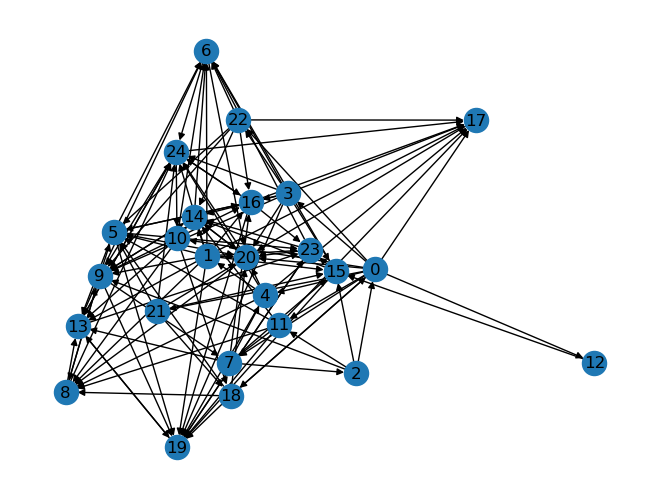

In [58]:
#Question 2 

RS = np.array([
    [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]],
    dtype = float)

GR = nx.DiGraph(RS.copy())
nx.draw(GR, with_labels=True)
print ("\nGraphe du réseau :\n")
plt.show()

In [61]:
#Algorithme pour le classement des comptes en fonction de leur nombre d'abonnés.

def classement(R) : 
    nbAbos = []
    for i in range (len(R)) :
        cpt = 0
        for j in range (len(R)) :
            if R[j][i] > 0 :
                cpt += 1.0
        nbAbos.append((i,cpt))
    nbAbos = sorted(nbAbos, key= lambda x : x[1],reverse = True)
    return nbAbos

print("\nClassement des comptes en fonction de leur nombre d'abonnés :\n(numéro du compte,nombre d'abonnés)\n")
print(classement(RS))
   
#Appliquer le PageRank
e = 10e-10

Xo = np.random.rand(len(RS))

TR = matriceTransition(transposee(RS), stochastique(transposee(RS)),a)

print("\nAlgorithme de la puissance itérée sur ce réseau :\n(numéro du compte,score)\n")
print(puissanceIteree(stochastique(TR), e,Xo))


Classement des comptes en fonction de leur nombre d'abonnés :
(numéro du compte,nombre d'abonnés)

[(19, 11.0), (20, 11.0), (6, 9.0), (14, 9.0), (24, 9.0), (13, 8.0), (17, 8.0), (5, 7.0), (8, 7.0), (9, 7.0), (16, 7.0), (15, 6.0), (23, 6.0), (7, 3.0), (18, 3.0), (0, 2.0), (4, 2.0), (10, 2.0), (11, 2.0), (22, 2.0), (1, 1.0), (2, 1.0), (3, 1.0), (12, 1.0), (21, 1.0)]

Algorithme de la puissance itérée sur ce réseau :
(numéro du compte,score)

[(25, 0.445125208689606), (21, 0.40498292322355234), (14, 0.3626314382594406), (24, 0.3058248545575147), (20, 0.29235189119256555), (15, 0.27601464696619366), (9, 0.24124304346927547), (10, 0.23970338740622882), (7, 0.22917283954995707), (17, 0.1546139115097786), (18, 0.14461869127456575), (11, 0.10102088521604677), (6, 0.09741038021332206), (16, 0.06839944081730111), (8, 0.055367646822966333), (19, 0.051125969862504964), (1, 0.03787896050881638), (5, 0.034762099732935085), (12, 0.03211455622969686), (3, 0.03183508914617741), (23, 0.0275043157673133

## Partie 5 : PageRank - calcul direct des scores et comparaisons d’algorithmes